# Consumer Trust in AI-Based Financial Advisory Tools  
## Practical Implementation using Machine Learning and Explainable AI  

### Objective of the Practical
The objective of this practical is to develop a machine learning framework to predict consumer trust in AI-based systems using a data-driven approach. The analysis focuses on identifying patterns in user behaviour and evaluating how different features are associated with trust.

### Dataset Source
This study uses the Women’s E-Commerce Clothing Reviews dataset available on Kaggle:  
https://www.kaggle.com/datasets/nicapotato/womens-ecommerce-clothing-reviews  

The dataset contains user reviews and ratings that represent interactions between users and recommendation systems.

### Definition of Trust
In this study, trust is operationalised using user ratings as a measurable indicator. Ratings reflect user evaluation of system outputs, including satisfaction, confidence, and perceived reliability.

The trust variable is defined as follows:

- High Trust = Rating ≥ 4  
- Low Trust = Rating < 4  

Ratings are used as a behavioral proxy for trust. They represent observable user responses rather than internal psychological states.

### Research Approach
This practical applies supervised machine learning models to classify trust levels and uses explainable AI techniques to interpret model predictions. The approach enables scalable analysis of trust using real user interaction data.

In [2]:
# Step 2: Import Libraries

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Text processing
import re

# Machine Learning - preprocessing and models
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Explainable AI
import shap

# Optional
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Step 3: Load Dataset

# Load dataset from Kaggle input directory
df = pd.read_csv('/kaggle/input/datasets/nicapotato/womens-ecommerce-clothing-reviews/Womens Clothing E-Commerce Reviews.csv')

# Display first 5 rows
print("First 5 rows of dataset:")
display(df.head())

# Show dataset shape
print("Dataset shape (rows, columns):")
print(df.shape)

# Show column names
print("Column names:")
print(df.columns.tolist())

First 5 rows of dataset:


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


Dataset shape (rows, columns):
(23486, 11)
Column names:
['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']


In [6]:
# Step 4: Initial Data Inspection

print("Dataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

# Missing values count
print("\nMissing Values per Column:")
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

# Duplicate rows count
duplicate_count = df.duplicated().sum()
print("\nNumber of Duplicate Rows:")
print(duplicate_count)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB

Statistical Summary:


,Unnamed: 0,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count
count,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000
mean,11742.500000,918.118709,43.198544,4.196032,0.822362,2.535936
std,6779.968547,203.298980,12.279544,1.110031,0.382216,5.702202
min,0.000000,0.000000,18.000000,1.000000,0.000000,0.000000
25%,5871.250000,861.000000,34.000000,4.000000,1.000000,0.000000
50%,11742.500000,936.000000,41.000000,5.000000,1.000000,1.000000
75%,17613.750000,1078.000000,52.000000,5.000000,1.000000,3.000000
max,23485.000000,1205.000000,99.000000,5.000000,1.000000,122.000000



Missing Values per Column:


Title              3810
Review Text         845
Division Name        14
Department Name      14
Class Name           14
dtype: int64


Number of Duplicate Rows:
0


In [10]:
# Step 5: Data Cleaning 
# Store initial shape
initial_shape = df.shape
print(f"Initial shape: {initial_shape}")

# 1. Remove unnecessary index column
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)
    print("Removed 'Unnamed: 0' column")

# 2. Check duplicates BEFORE removal
duplicates_before = df.duplicated().sum()
print(f"\nDuplicate rows before cleaning: {duplicates_before}")

# Remove duplicates
df = df.drop_duplicates()

# Check duplicates AFTER removal
duplicates_after = df.duplicated().sum()
print(f"Duplicate rows after cleaning: {duplicates_after}")

# 3. Handle missing text data
df['Title'] = df['Title'].fillna("")
df['Review Text'] = df['Review Text'].fillna("")
print("\nFilled missing values in text columns")

# 4. Handle missing categorical values
categorical_cols = ['Division Name', 'Department Name', 'Class Name']

for col in categorical_cols:
    missing_count = df[col].isnull().sum()
    if missing_count > 0:
        df[col] = df[col].fillna("Unknown")
        print(f"Filled {missing_count} missing values in '{col}'")

# 5. Check numeric columns for missing values
numeric_missing = df.select_dtypes(include=['int64', 'float64']).isnull().sum()

print("\nMissing values in numeric columns:")
if numeric_missing.sum() == 0:
    print("No missing values in numeric columns")
else:
    print(numeric_missing[numeric_missing > 0])

# Final shape comparison
final_shape = df.shape
rows_removed = initial_shape[0] - final_shape[0]

print("\nFinal Dataset Summary:")
print(f"Final shape: {final_shape}")
print(f"Rows removed during cleaning: {rows_removed}")

Initial shape: (23465, 10)

Duplicate rows before cleaning: 0
Duplicate rows after cleaning: 0

Filled missing values in text columns

Missing values in numeric columns:
No missing values in numeric columns

Final Dataset Summary:
Final shape: (23465, 10)
Rows removed during cleaning: 0


trust_label created successfully

Class Distribution (Counts):
trust_label
1    18187
0     5278
Name: count, dtype: int64

Class Distribution (Percentage):
trust_label
1    77.51
0    22.49
Name: proportion, dtype: float64


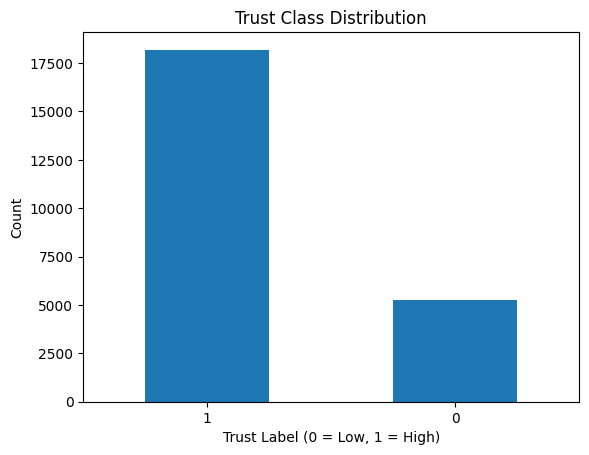


Target Variable Ready for Classification


In [12]:
# Step 6: Target Variable Construction


# Create binary trust label
df['trust_label'] = df['Rating'].apply(lambda x: 1 if x >= 4 else 0)

print("trust_label created successfully")

# Show class counts
print("\nClass Distribution (Counts):")
class_counts = df['trust_label'].value_counts()
print(class_counts)

# Show percentage distribution
print("\nClass Distribution (Percentage):")
class_percent = df['trust_label'].value_counts(normalize=True) * 100
print(class_percent.round(2))

# Optional: Visualisation
import matplotlib.pyplot as plt

plt.figure()
df['trust_label'].value_counts().plot(kind='bar')
plt.title("Trust Class Distribution")
plt.xlabel("Trust Label (0 = Low, 1 = High)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

print("\nTarget Variable Ready for Classification")

In [14]:
# Step 7: Data Leakage Validation

# Define target variable
y = df['trust_label']

# Define feature set (remove target + rating)
X = df.drop(columns=['trust_label', 'Rating'])

# Show feature columns
print("Feature columns used for modelling:")
print(X.columns.tolist())

# Check if Rating is present
if 'Rating' in X.columns:
    print("\nData Leakage Detected: 'Rating' is still in features")
else:
    print("\n'Rating' successfully removed from features")

# Final validation
leakage_cols = [col for col in X.columns if 'rating' in col.lower()]

if len(leakage_cols) == 0:
    print("No rating-related features found")
else:
    print(f"Potential leakage columns found: {leakage_cols}")

Feature columns used for modelling:
['Clothing ID', 'Age', 'Title', 'Review Text', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']

'Rating' successfully removed from features
No rating-related features found


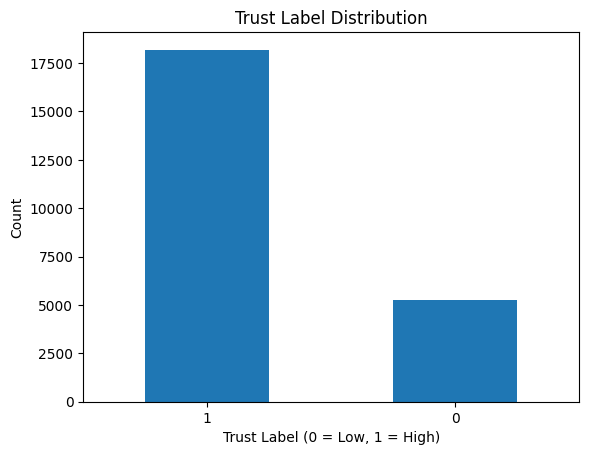

Class Counts:
trust_label
1    18187
0     5278
Name: count, dtype: int64

Class Percentage:
trust_label
1    77.51
0    22.49
Name: count, dtype: float64

Class Ratio (majority/minority): 3.45
Dataset is imbalanced


In [16]:
# Step 8: Class Imbalance Check

# Count values
class_counts = df['trust_label'].value_counts()

# Plot bar chart
plt.figure()
class_counts.plot(kind='bar')

plt.title("Trust Label Distribution")
plt.xlabel("Trust Label (0 = Low, 1 = High)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# Print counts and percentages
print("Class Counts:")
print(class_counts)

print("\nClass Percentage:")
class_percent = (class_counts / len(df)) * 100
print(class_percent.round(2))

# Simple imbalance check
ratio = class_counts.max() / class_counts.min()

print(f"\nClass Ratio (majority/minority): {round(ratio,2)}")

if ratio > 1.5:
    print("Dataset is imbalanced")
else:
    print("Dataset is balanced")


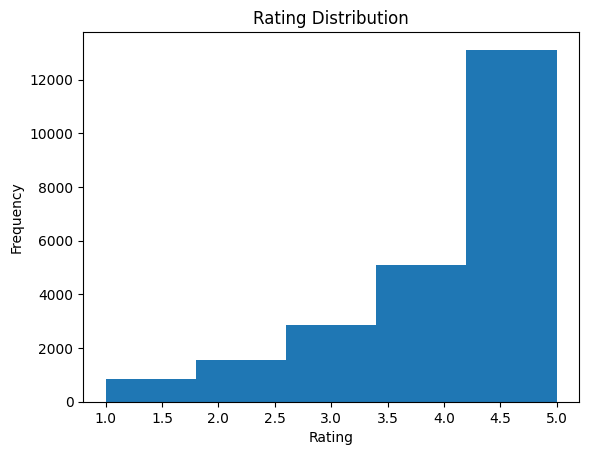

In [18]:
# Step 9: Exploratory Data Analysis (EDA)

# 9.1 Rating Distribution

plt.figure()
df['Rating'].plot(kind='hist', bins=5)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()


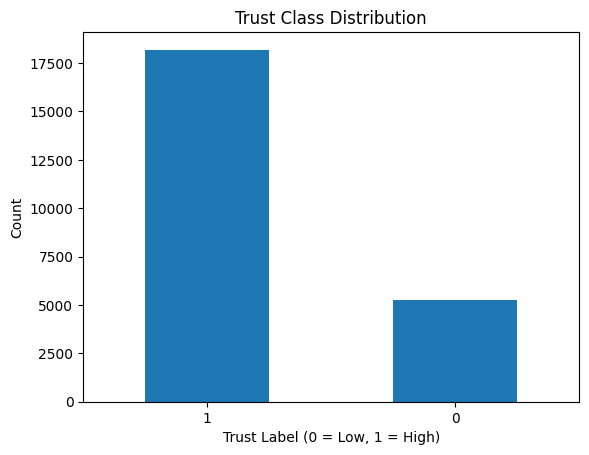

In [19]:
# 9.2 Trust Class Distribution

plt.figure()
df['trust_label'].value_counts().plot(kind='bar')
plt.title("Trust Class Distribution")
plt.xlabel("Trust Label (0 = Low, 1 = High)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

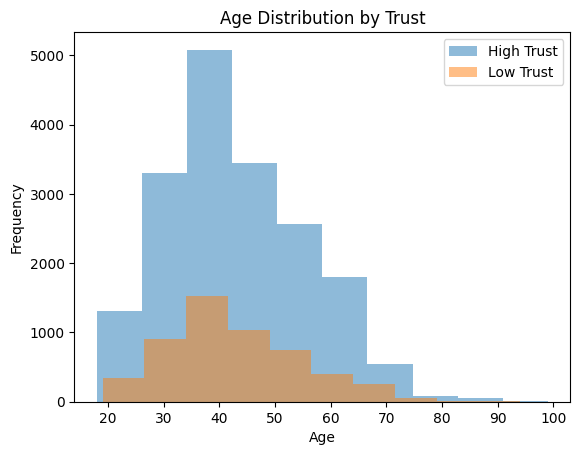

In [20]:
# 9.3 Age vs Trust
plt.figure()
df[df['trust_label'] == 1]['Age'].plot(kind='hist', alpha=0.5, label='High Trust')
df[df['trust_label'] == 0]['Age'].plot(kind='hist', alpha=0.5, label='Low Trust')
plt.title("Age Distribution by Trust")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.legend()
plt.show()

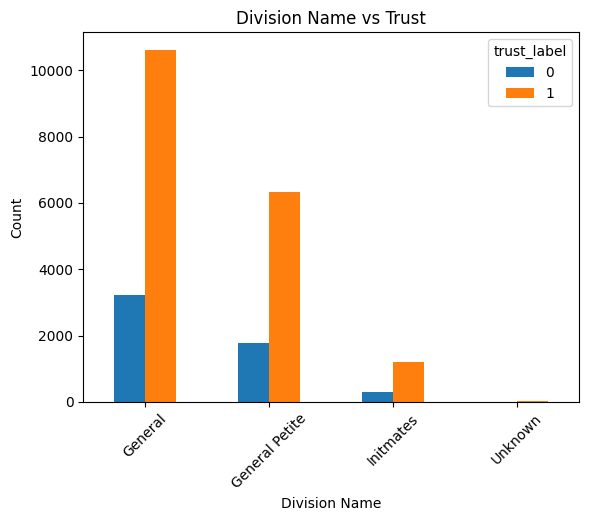

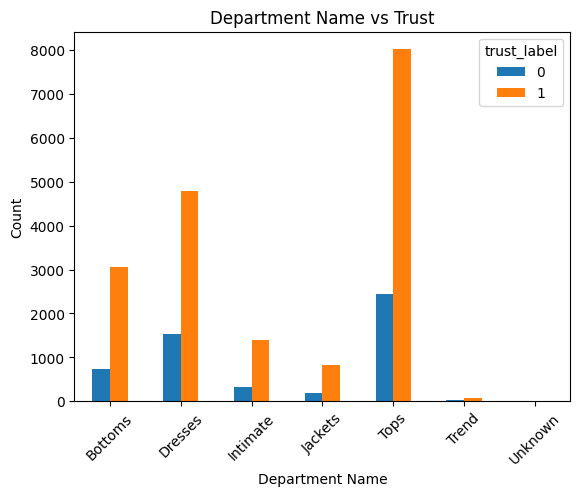

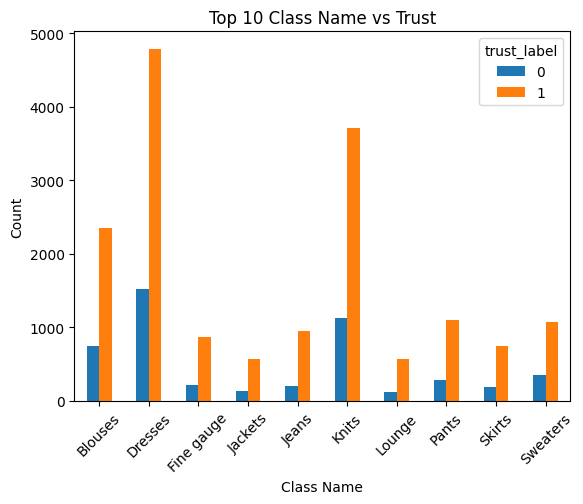

In [21]:
# 9.4 Category vs Trust
# Division Name
division_trust = pd.crosstab(df['Division Name'], df['trust_label'])
division_trust.plot(kind='bar')
plt.title("Division Name vs Trust")
plt.xlabel("Division Name")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Department Name
department_trust = pd.crosstab(df['Department Name'], df['trust_label'])
department_trust.plot(kind='bar')
plt.title("Department Name vs Trust")
plt.xlabel("Department Name")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Class Name (top 10 only for clarity)
top_classes = df['Class Name'].value_counts().head(10).index
class_trust = pd.crosstab(df[df['Class Name'].isin(top_classes)]['Class Name'], df['trust_label'])
class_trust.plot(kind='bar')
plt.title("Top 10 Class Name vs Trust")
plt.xlabel("Class Name")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

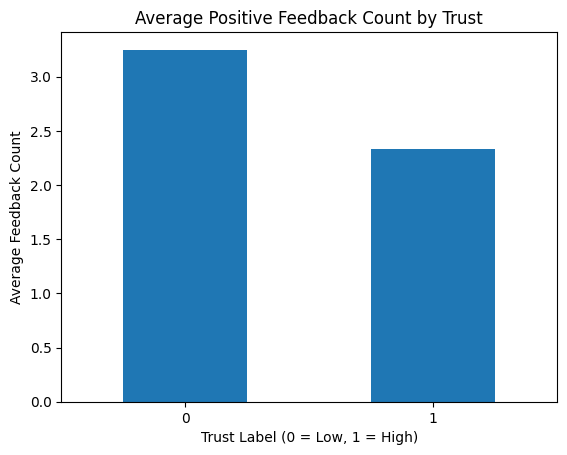

In [22]:
# 9.5 Positive Feedback vs Trust
plt.figure()
df.groupby('trust_label')['Positive Feedback Count'].mean().plot(kind='bar')
plt.title("Average Positive Feedback Count by Trust")
plt.xlabel("Trust Label (0 = Low, 1 = High)")
plt.ylabel("Average Feedback Count")
plt.xticks(rotation=0)
plt.show()

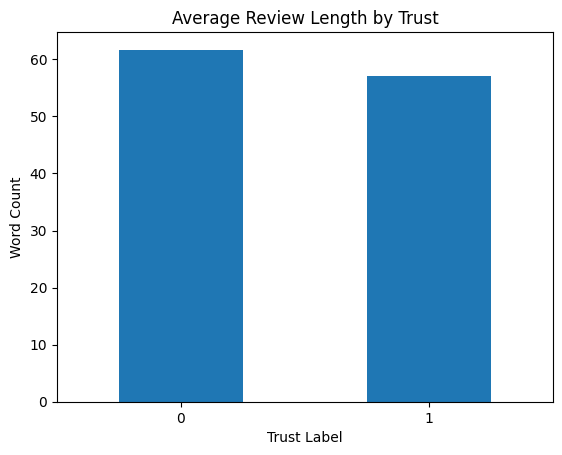

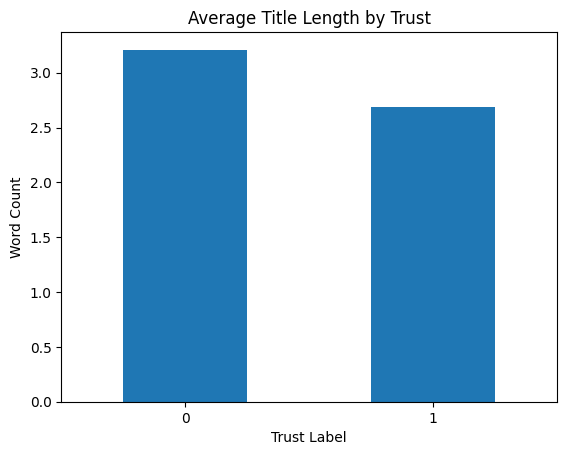

In [23]:
# 9.6 Review Length Analysis
# Create word count features
df['review_length'] = df['Review Text'].apply(lambda x: len(x.split()))
df['title_length'] = df['Title'].apply(lambda x: len(x.split()))

# Plot review length
plt.figure()
df.groupby('trust_label')['review_length'].mean().plot(kind='bar')
plt.title("Average Review Length by Trust")
plt.xlabel("Trust Label")
plt.ylabel("Word Count")
plt.xticks(rotation=0)
plt.show()

# Plot title length
plt.figure()
df.groupby('trust_label')['title_length'].mean().plot(kind='bar')
plt.title("Average Title Length by Trust")
plt.xlabel("Trust Label")
plt.ylabel("Word Count")
plt.xticks(rotation=0)
plt.show()

In [24]:
# Step 10: Text Preprocessing

# 1. Combine Title and Review Text
df['combined_text'] = df['Title'] + " " + df['Review Text']

print("Combined 'Title' and 'Review Text'")

# 2. Convert to lowercase
df['combined_text'] = df['combined_text'].str.lower()

# 3. Remove punctuation
df['combined_text'] = df['combined_text'].apply(lambda x: re.sub(r'[^\w\s]', '', x))

# 4. Remove extra spaces
df['combined_text'] = df['combined_text'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

print("Cleaned text (lowercase, punctuation removed, spaces normalized)")

# 5. Preview cleaned text
print("\nSample cleaned text:")
display(df[['combined_text']].head())

Combined 'Title' and 'Review Text'
Cleaned text (lowercase, punctuation removed, spaces normalized)

Sample cleaned text:


,combined_text
0,absolutely wonderful silky and sexy and comfor...
1,love this dress its sooo pretty i happened to ...
2,some major design flaws i had such high hopes ...
3,my favorite buy i love love love this jumpsuit...
4,flattering shirt this shirt is very flattering...


In [26]:
# Step 11: Feature Engineering

# 1. Numeric features (already present)
# Age and Positive Feedback Count will be used directly

# 2. Review length (already created in EDA, ensure consistency)
df['review_length'] = df['Review Text'].apply(lambda x: len(x.split()))

# 3. Title length
df['title_length'] = df['Title'].apply(lambda x: len(x.split()))

print("Created text-based length features")

# 4. Select final feature columns
feature_columns = [
    'Age',
    'Positive Feedback Count',
    'review_length',
    'title_length',
    'Division Name',
    'Department Name',
    'Class Name',
    'combined_text'
]

# Create feature dataset
X = df[feature_columns]

# Target variable
y = df['trust_label']

print("\nFeature Columns:")
print(feature_columns)

print("\nFeature Dataset Shape:")
print(X.shape)

print("\nTarget Distribution:")
print(y.value_counts())

Created text-based length features

Feature Columns:
['Age', 'Positive Feedback Count', 'review_length', 'title_length', 'Division Name', 'Department Name', 'Class Name', 'combined_text']

Feature Dataset Shape:
(23465, 8)

Target Distribution:
trust_label
1    18187
0     5278
Name: count, dtype: int64


In [29]:
# Step 12: Feature Encoding and Vectorisation

from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

# 1. Feature groups
numeric_features = ['Age', 'Positive Feedback Count', 'review_length', 'title_length']
categorical_features = ['Division Name', 'Department Name', 'Class Name']
text_feature = 'combined_text'

# 2. One-Hot Encoding
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
X_cat = ohe.fit_transform(df[categorical_features])

print("Categorical features encoded")

# 3. TF-IDF Vectorisation
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_text = tfidf.fit_transform(df[text_feature])

print("Text features vectorised using TF-IDF")

# 4. Numeric features
X_num = df[numeric_features].values

print("Numeric features prepared")

# 5. Combine all features
X_final = hstack([X_num, X_cat, X_text])

print("\nFinal Feature Matrix Shape:")
print(X_final.shape)

Categorical features encoded
Text features vectorised using TF-IDF
Numeric features prepared

Final Feature Matrix Shape:
(23465, 5036)


In [30]:
# Step 13: Train-Test Split

from sklearn.model_selection import train_test_split

# Split data (80% train, 20% test) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Print shapes
print("Dataset Shapes:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

# Check class distribution
print("\nClass Distribution in Training Set:")
print(y_train.value_counts(normalize=True).round(3))

print("\nClass Distribution in Testing Set:")
print(y_test.value_counts(normalize=True).round(3))

Dataset Shapes:
X_train: (18772, 5036)
X_test: (4693, 5036)
y_train: (18772,)
y_test: (4693,)

Class Distribution in Training Set:
trust_label
1    0.775
0    0.225
Name: proportion, dtype: float64

Class Distribution in Testing Set:
trust_label
1    0.775
0    0.225
Name: proportion, dtype: float64


In [31]:
# Step 14: Logistic Regression (Baseline Model)

print("Training Logistic Regression Model...\n")

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Initialize model
lr_model = LogisticRegression(max_iter=1000)

# Train model
lr_model.fit(X_train, y_train)

print("Model training completed")

# Predictions
y_pred = lr_model.predict(X_test)
y_prob = lr_model.predict_proba(X_test)[:, 1]

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Print results
print("\nLogistic Regression Performance:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


Training Logistic Regression Model...

Model training completed

Logistic Regression Performance:
Accuracy:  0.8788
Precision: 0.8899
Recall:    0.9626
F1-Score:  0.9248
ROC-AUC:   0.9255

Confusion Matrix:
[[ 623  433]
 [ 136 3501]]


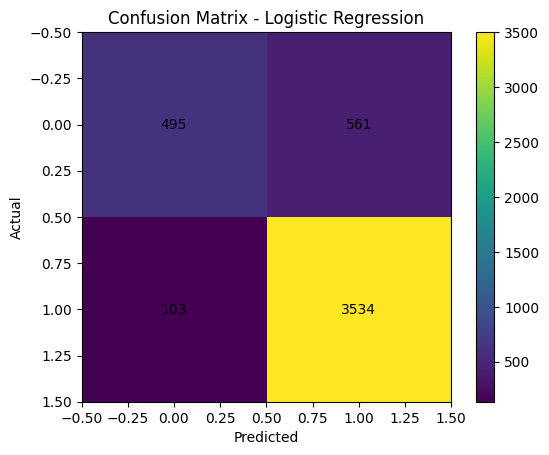

In [38]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix - Logistic Regression")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm_xgb.shape[0]):
    for j in range(cm_xgb.shape[1]):
        plt.text(j, i, cm_xgb[i, j],
                 ha="center", va="center")
plt.show()

In [33]:
# Step 15: Random Forest Model

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train, y_train)

print("Model training completed")

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

# Print results
print("\nRandom Forest Performance:")
print(f"Accuracy:  {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1-Score:  {f1_rf:.4f}")
print(f"ROC-AUC:   {roc_auc_rf:.4f}")

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("\nConfusion Matrix:")
print(cm_rf)

Model training completed

Random Forest Performance:
Accuracy:  0.8536
Precision: 0.8565
Recall:    0.9744
F1-Score:  0.9116
ROC-AUC:   0.8983

Confusion Matrix:
[[ 462  594]
 [  93 3544]]


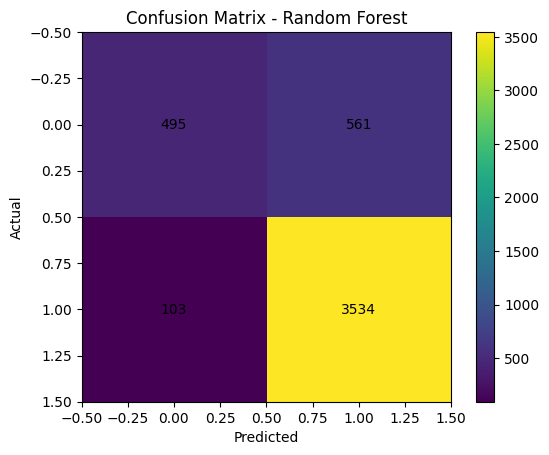

In [37]:
plt.figure()
plt.imshow(cm_rf)
plt.title("Confusion Matrix - Random Forest")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm_xgb.shape[0]):
    for j in range(cm_xgb.shape[1]):
        plt.text(j, i, cm_xgb[i, j],
                 ha="center", va="center")
plt.show()

In [35]:
# Step 16: XGBoost Model

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Initialize model
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Train model
xgb_model.fit(X_train, y_train)

print("Model training completed")

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

# Print results
print("\nXGBoost Performance:")
print(f"Accuracy:  {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall:    {recall_xgb:.4f}")
print(f"F1-Score:  {f1_xgb:.4f}")
print(f"ROC-AUC:   {roc_auc_xgb:.4f}")

# Confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print("\nConfusion Matrix:")
print(cm_xgb)

Model training completed

XGBoost Performance:
Accuracy:  0.8585
Precision: 0.8630
Recall:    0.9717
F1-Score:  0.9141
ROC-AUC:   0.8997

Confusion Matrix:
[[ 495  561]
 [ 103 3534]]


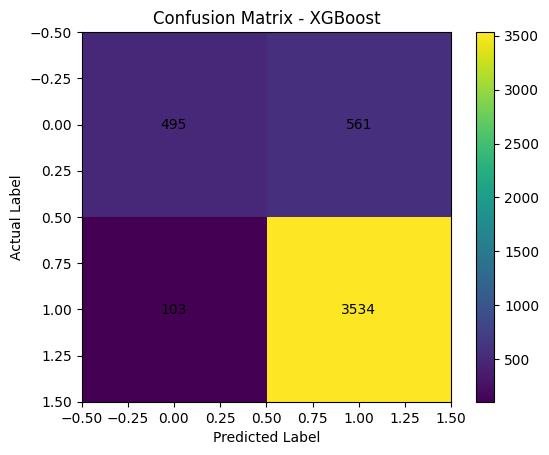

In [36]:
# Confusion Matrix Visualization for XGBoost

import matplotlib.pyplot as plt

plt.figure()
plt.imshow(cm_xgb)
plt.title("Confusion Matrix - XGBoost")
plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

# Add values inside the matrix
for i in range(cm_xgb.shape[0]):
    for j in range(cm_xgb.shape[1]):
        plt.text(j, i, cm_xgb[i, j],
                 ha="center", va="center")

plt.show()

In [40]:
# Step 17: Cross-Validation (5-Fold)

from sklearn.model_selection import cross_val_score

# Apply 5-fold cross-validation on XGBoost
cv_scores = cross_val_score(
    xgb_model,
    X_final,
    y,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Results
print("Cross-Validation Accuracy Scores:")
print(cv_scores)

print("\nMean Accuracy:")
print(round(cv_scores.mean(), 4))

print("\nStandard Deviation:")
print(round(cv_scores.std(), 4))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:01:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:01:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:01:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:01:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Cross-Validation Accuracy Scores:
[0.85936501 0.86383976 0.86490518 0.85915193 0.85893885]

Mean Accuracy:
0.8612

Standard Deviation:
0.0026


In [41]:
# Step 18: Hyperparameter Tuning (XGBoost)

from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score

# Define parameter grid (light tuning)
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1]
}

# Initialize base model
xgb_base = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Grid Search
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit model
grid_search.fit(X_train, y_train)

print("\n✔ Best Parameters Found:")
print(grid_search.best_params_)

# Best model
xgb_tuned = grid_search.best_estimator_

# Predictions
y_pred_tuned = xgb_tuned.predict(X_test)
y_prob_tuned = xgb_tuned.predict_proba(X_test)[:, 1]

# Evaluation
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

print("\nTuned Model Performance:")
print(f"Accuracy: {accuracy_tuned:.4f}")
print(f"F1-Score: {f1_tuned:.4f}")

# Compare with default model
print("\nComparison with Default XGBoost:")
print(f"Default Accuracy: {accuracy_xgb:.4f}")
print(f"Tuned Accuracy:   {accuracy_tuned:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:05:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:05:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:05:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:05:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:


✔ Best Parameters Found:
{'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 150}

Tuned Model Performance:
Accuracy: 0.8613
F1-Score: 0.9152

Comparison with Default XGBoost:
Default Accuracy: 0.8585
Tuned Accuracy:   0.8613


In [42]:
# Step 19: Model Comparison Table

import pandas as pd

# Create comparison table
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [accuracy, accuracy_rf, accuracy_xgb],
    'Precision': [precision, precision_rf, precision_xgb],
    'Recall': [recall, recall_rf, recall_xgb],
    'F1-Score': [f1, f1_rf, f1_xgb],
    'ROC-AUC': [roc_auc, roc_auc_rf, roc_auc_xgb]
})

# Round values for better display
model_comparison = model_comparison.round(4)

# Display table
display(model_comparison)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8788,0.8899,0.9626,0.9248,0.9255
1,Random Forest,0.8536,0.8565,0.9744,0.9116,0.8983
2,XGBoost,0.8585,0.8630,0.9717,0.9141,0.8997


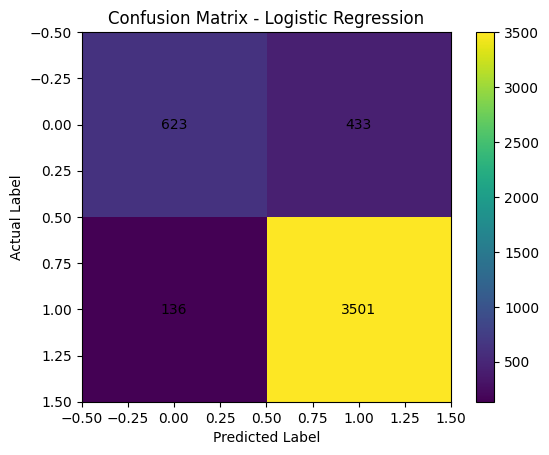

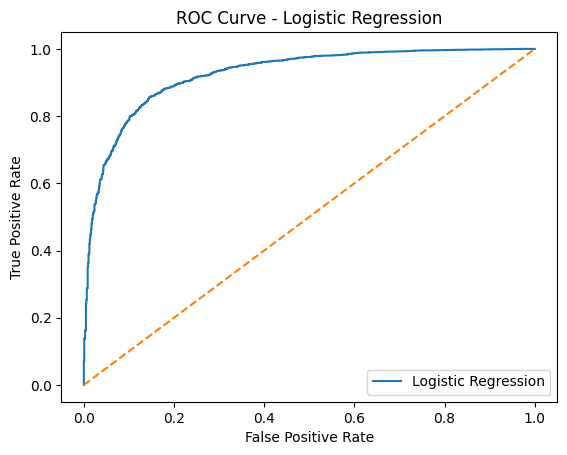

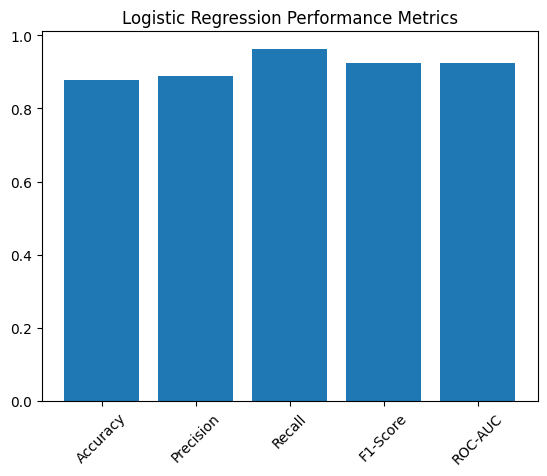

In [43]:
# Step 20: Visual Evaluation (Logistic Regression)

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# -----------------------------
# 1. Confusion Matrix Plot
# -----------------------------
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix - Logistic Regression")
plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

# Add values inside matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.show()

# 2. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle='--')  # baseline

plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


# 3. Optional: Metric Comparison Chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
values = [accuracy, precision, recall, f1, roc_auc]

plt.figure()
plt.bar(metrics, values)
plt.title("Logistic Regression Performance Metrics")
plt.xticks(rotation=45)
plt.show()

SHAP values computed

Global Feature Importance (SHAP Summary Plot)


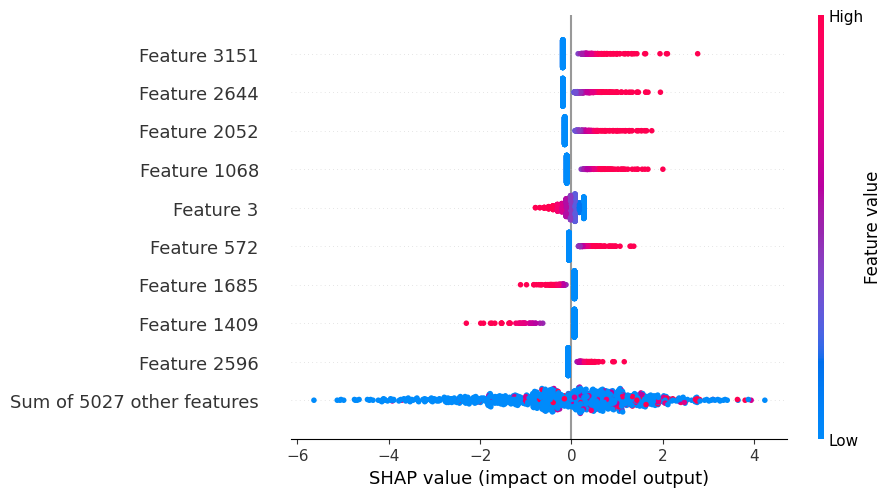


SHAP Feature Importance (Bar Plot)


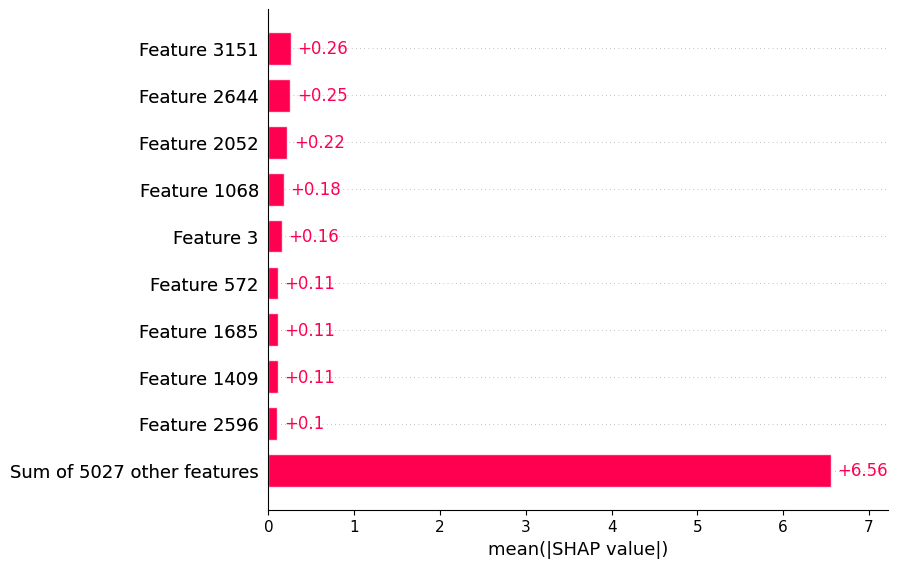


Local Explanation (Single Prediction)


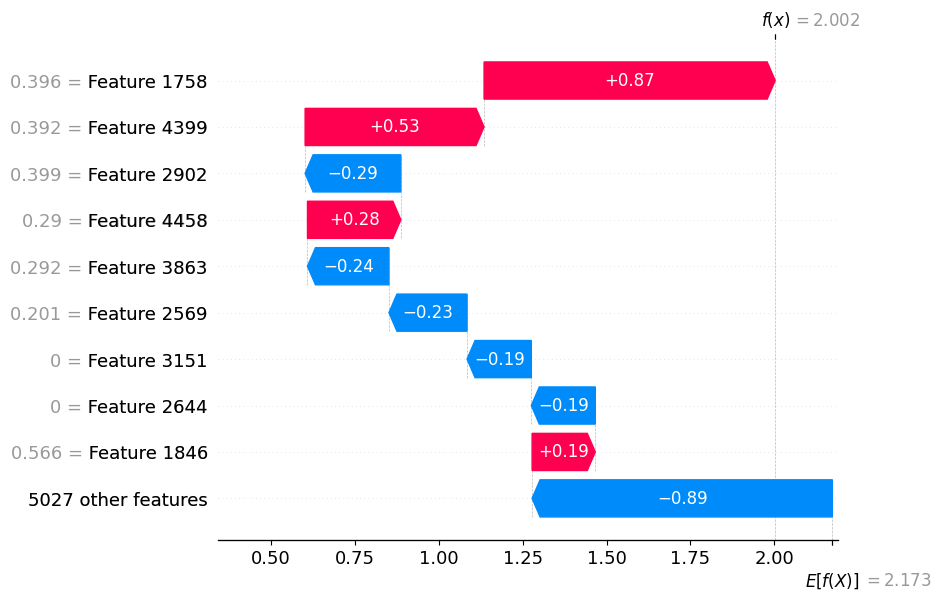

In [44]:
# Step 21: Explainable AI (SHAP)

import shap

# Use a smaller sample for speed
sample_size = 1000
X_sample = X_test[:sample_size]

# Create SHAP explainer
explainer = shap.Explainer(lr_model, X_sample)

# Compute SHAP values
shap_values = explainer(X_sample)

print("SHAP values computed")

# 1. Global Interpretation
print("\nGlobal Feature Importance (SHAP Summary Plot)")
shap.plots.beeswarm(shap_values)


# 2. Feature Importance Bar Plot
print("\nSHAP Feature Importance (Bar Plot)")
shap.plots.bar(shap_values)


# 3. Local Interpretation
print("\nLocal Explanation (Single Prediction)")
shap.plots.waterfall(shap_values[0])

In [45]:
# Step 22: Trust Driver Interpretation

import numpy as np
import pandas as pd

# Convert SHAP values to array
shap_vals = shap_values.values

# Calculate mean absolute SHAP values (global importance)
mean_shap = np.abs(shap_vals).mean(axis=0)

# Get feature names
feature_names = X_train.shape[1]

# If feature names not available directly (due to sparse matrix)
# create index-based feature names
feature_list = [f"Feature_{i}" for i in range(X_final.shape[1])]

# Create DataFrame for interpretation
shap_importance = pd.DataFrame({
    'Feature': feature_list,
    'Importance': mean_shap
})

# Sort by importance
shap_importance = shap_importance.sort_values(by='Importance', ascending=False)

# Display top 10 features
print("Top 10 Important Features:")
display(shap_importance.head(10))

Top 10 Important Features:


,Feature,Importance
3151,Feature_3151,0.257650
2644,Feature_2644,0.252998
2052,Feature_2052,0.221217
1068,Feature_1068,0.175302
3,Feature_3,0.158938
572,Feature_572,0.111704
1685,Feature_1685,0.108235
1409,Feature_1409,0.105601
2596,Feature_2596,0.104588
4043,Feature_4043,0.098123


In [46]:
# Step 23: Ablation Study and Sensitivity Analysis

from sklearn.metrics import accuracy_score, f1_score

# Helper function to train & evaluate
def evaluate_model(X_train_mod, X_test_mod, y_train, y_test, model):
    model.fit(X_train_mod, y_train)
    preds = model.predict(X_test_mod)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    return acc, f1


# 1. Baseline (Full Features)
baseline_acc = accuracy
baseline_f1 = f1

print("Baseline Model (All Features)")
print(f"Accuracy: {baseline_acc:.4f}")
print(f"F1-Score: {baseline_f1:.4f}\n")


# 2. Remove TEXT features
print("Removing TEXT features...")

# Keep only numeric + categorical
X_num_cat = hstack([X_num, X_cat])

# Split again (same random state + stratify)
X_train_nc, X_test_nc, y_train_nc, y_test_nc = train_test_split(
    X_num_cat, y, test_size=0.2, random_state=42, stratify=y
)

acc_nc, f1_nc = evaluate_model(X_train_nc, X_test_nc, y_train_nc, y_test_nc, LogisticRegression(max_iter=1000))

print(f"Accuracy (No Text): {acc_nc:.4f}")
print(f"F1-Score (No Text): {f1_nc:.4f}\n")


# -----------------------------
# 3. Remove NUMERIC features
# -----------------------------
print("Removing NUMERIC features...")

# Keep only categorical + text
X_cat_text = hstack([X_cat, X_text])

X_train_ct, X_test_ct, y_train_ct, y_test_ct = train_test_split(
    X_cat_text, y, test_size=0.2, random_state=42, stratify=y
)

acc_ct, f1_ct = evaluate_model(X_train_ct, X_test_ct, y_train_ct, y_test_ct, LogisticRegression(max_iter=1000))

print(f"Accuracy (No Numeric): {acc_ct:.4f}")
print(f"F1-Score (No Numeric): {f1_ct:.4f}\n")


# -----------------------------
# 4. Remove CATEGORICAL features
# -----------------------------
print("Removing CATEGORICAL features...")

# Keep only numeric + text
X_num_text = hstack([X_num, X_text])

X_train_nt, X_test_nt, y_train_nt, y_test_nt = train_test_split(
    X_num_text, y, test_size=0.2, random_state=42, stratify=y
)

acc_nt, f1_nt = evaluate_model(X_train_nt, X_test_nt, y_train_nt, y_test_nt, LogisticRegression(max_iter=1000))

print(f"Accuracy (No Categorical): {acc_nt:.4f}")
print(f"F1-Score (No Categorical): {f1_nt:.4f}\n")


# -----------------------------
# Summary Table
# -----------------------------
import pandas as pd

ablation_results = pd.DataFrame({
    "Scenario": [
        "All Features",
        "Without Text",
        "Without Numeric",
        "Without Categorical"
    ],
    "Accuracy": [
        baseline_acc,
        acc_nc,
        acc_ct,
        acc_nt
    ],
    "F1-Score": [
        baseline_f1,
        f1_nc,
        f1_ct,
        f1_nt
    ]
})

print("Ablation Study Summary:")
display(ablation_results.round(4))

Baseline Model (All Features)
Accuracy: 0.8788
F1-Score: 0.9248

Removing TEXT features...
Accuracy (No Text): 0.7752
F1-Score (No Text): 0.8733

Removing NUMERIC features...
Accuracy (No Numeric): 0.8792
F1-Score (No Numeric): 0.9253

Removing CATEGORICAL features...
Accuracy (No Categorical): 0.8790
F1-Score (No Categorical): 0.9250

Ablation Study Summary:


,Scenario,Accuracy,F1-Score
0,All Features,0.8788,0.9248
1,Without Text,0.7752,0.8733
2,Without Numeric,0.8792,0.9253
3,Without Categorical,0.8790,0.9250


In [50]:
# Prediction using real dataset samples

# -----------------------------
# 1. Take random sample from dataset
# -----------------------------
sample_df = df.sample(20, random_state=42)

# Keep only required columns
sample_input = sample_df[[
    'Age',
    'Positive Feedback Count',
    'review_length',
    'title_length',
    'Division Name',
    'Department Name',
    'Class Name',
    'combined_text'
]]

# -----------------------------
# 2. Encode categorical
# -----------------------------
X_cat_new = ohe.transform(sample_input[['Division Name', 'Department Name', 'Class Name']])

# -----------------------------
# 3. TF-IDF transform text
# -----------------------------
X_text_new = tfidf.transform(sample_input['combined_text'])

# -----------------------------
# 4. Numeric features
# -----------------------------
X_num_new = sample_input[['Age', 'Positive Feedback Count', 'review_length', 'title_length']].values

# -----------------------------
# 5. Combine all features
# -----------------------------
from scipy.sparse import hstack
X_new_final = hstack([X_num_new, X_cat_new, X_text_new])

# -----------------------------
# 6. Predict
# -----------------------------
predictions = lr_model.predict(X_new_final)
probabilities = lr_model.predict_proba(X_new_final)[:, 1]

# -----------------------------
# 7. Show results
# -----------------------------
results = sample_df.copy()
results['Predicted Trust'] = predictions
results['Prediction Confidence'] = probabilities.round(4)

display(results[['Age', 'Rating', 'Predicted Trust', 'Prediction Confidence', 'Review Text']])

,Age,Rating,Predicted Trust,Prediction Confidence,Review Text
11922,52,4,0,0.4092,I have literally dozens of deletta tops. just ...
3276,38,5,1,0.9978,I actually love these jeans. i feel they run t...
7734,53,5,1,0.9782,Very flattering dress in a comfortable materia...
3503,36,3,0,0.1020,I really loved the color and fabric of this sw...
17611,81,5,1,0.9019,"Unique vest: modern, chic. i especially like t..."
6359,56,5,1,0.9915,This vest is the one thing i will wear all yea...
12980,35,4,1,0.8996,They were sold out of the medium that i usuall...
12265,57,3,1,0.6402,I was so excited to receive this romper. it's ...
21996,39,4,1,0.9353,"Also, a little on the bigger size, i ended up ..."
13446,45,4,1,0.9581,Cute and comfy! i usually wear a small but bou...
